<a href="https://colab.research.google.com/github/Tlevi308/DS_PROJECTS/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression

## Importing the Lib's

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the Data

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bank-marketing-dataset' dataset.
Path to dataset files: /kaggle/input/bank-marketing-dataset


In [3]:
data_file_path = '/kaggle/input/bank-marketing-dataset/bank.csv'
df = pd.read_csv(data_file_path) # Assuming semicolon separator based on common bank marketing datasets
display(df.head())
df.columns.tolist()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'deposit']

In [4]:
columns_to_drop = [
    'contact',
    'day',
    'month',
    'duration',
    'pdays',
    'previous',
    'poutcome'
]

df = df.drop(columns=columns_to_drop, errors='ignore')
display(df.head())

,age,job,marital,education,default,balance,housing,loan,campaign,deposit
0,59,admin.,married,secondary,no,2343,yes,no,1,yes
1,56,admin.,married,secondary,no,45,no,no,1,yes
2,41,technician,married,secondary,no,1270,yes,no,1,yes
3,55,services,married,secondary,no,2476,yes,no,1,yes
4,54,admin.,married,tertiary,no,184,no,no,2,yes


## EDA

### 1. DataFrame Dimensions and Information

In [5]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print("\nDataFrame Info:")
df.info()

Number of rows: 11162
Number of columns: 10

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   campaign   11162 non-null  int64 
 9   deposit    11162 non-null  object
dtypes: int64(3), object(7)
memory usage: 872.2+ KB


### 2. Missing Values

In [6]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
campaign     0
deposit      0
dtype: int64


### 3. Duplicate Rows

In [7]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 312


### 4. Unique Values and Value Counts for Categorical Features

In [8]:
for column in df.select_dtypes(include='object').columns:
    print(f"\nColumn '{column}':")
    print(f"Number of unique values: {df[column].nunique()}")
    print(df[column].value_counts())


Column 'job':
Number of unique values: 12
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

Column 'marital':
Number of unique values: 3
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64

Column 'education':
Number of unique values: 4
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64

Column 'default':
Number of unique values: 2
default
no     10994
yes      168
Name: count, dtype: int64

Column 'housing':
Number of unique values: 2
housing
no     5881
yes    5281
Name: count, dtype: int64

Column 'loan':
Number of unique values: 2
loan
no     9702
yes    1460
Name: count, dtype: int64

Column 'deposit':
Number of unique values: 2
deposit
no     5873
ye

### 5. Descriptive Statistics (סטטיסטיקה תיאורית)

In [9]:
print("Descriptive statistics for numerical columns:")
display(df.describe())

Descriptive statistics for numerical columns:


,age,balance,campaign
count,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,2.508421
std,11.913369,3225.413326,2.722077
min,18.000000,-6847.000000,1.000000
25%,32.000000,122.000000,1.000000
50%,39.000000,550.000000,2.000000
75%,49.000000,1708.000000,3.000000
max,95.000000,81204.000000,63.000000


/tmp/ipykernel_1687/2178827306.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='campaign', data=df, palette='viridis')


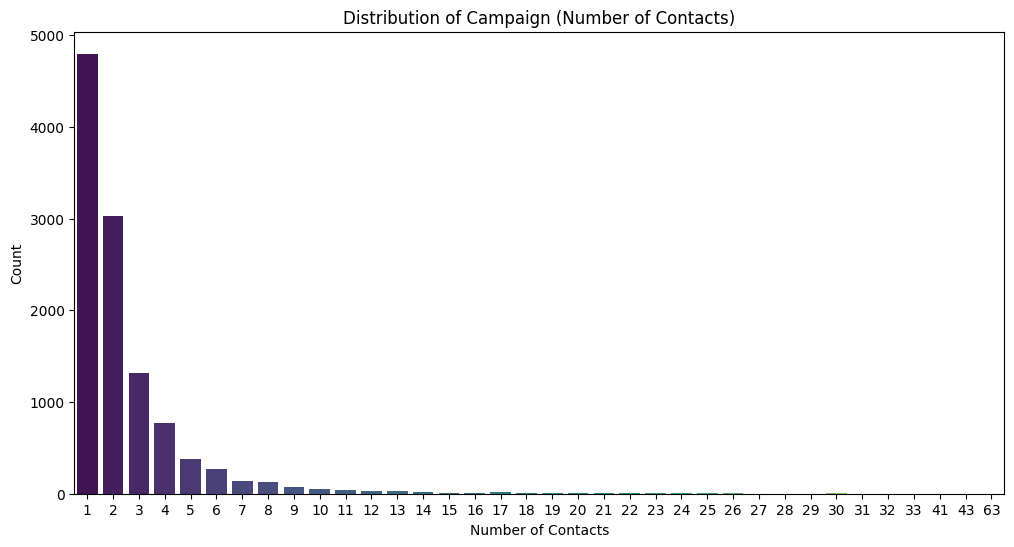

Summary Statistics for Campaign:
count    11162.000000
mean         2.508421
std          2.722077
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         63.000000
Name: campaign, dtype: float64

Value Counts for Campaign (Number of Contacts):


,count
campaign,
1,4798
2,3028
3,1321
4,771
5,378
6,265
7,139
8,128
9,72


In [13]:
plt.figure(figsize=(12, 6))
sns.countplot(x='campaign', data=df, palette='viridis')
plt.title('Distribution of Campaign (Number of Contacts)')
plt.xlabel('Number of Contacts')
plt.ylabel('Count')
plt.show()

print("Summary Statistics for Campaign:")
print(df['campaign'].describe())

print("\nValue Counts for Campaign (Number of Contacts):")
display(df['campaign'].value_counts().sort_index())

In [21]:
df['campaign'] = df['campaign'].clip(upper=5)
# Map numeric campaign values to strings
campaign_map = {i: f'camp_{i}' for i in range(1, 6)}
df['campaign'] = df['campaign'].map(campaign_map)

print("New value counts for Campaign (string labels):")
display(df['campaign'].value_counts().sort_index())

New value counts for Campaign (string labels):


,count
campaign,
camp_1,4798
camp_2,3028
camp_3,1321
camp_4,771
camp_5,1244


In [22]:
print("Descriptive statistics for categorical columns:")
display(df.describe(include='object'))

Descriptive statistics for categorical columns:


,job,marital,education,default,housing,loan,campaign
count,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,5
top,management,married,secondary,no,no,no,camp_1
freq,2566,6351,5476,10994,5881,9702,4798


### 6. Distributions and Outliers (התפלגויות וחריגים)

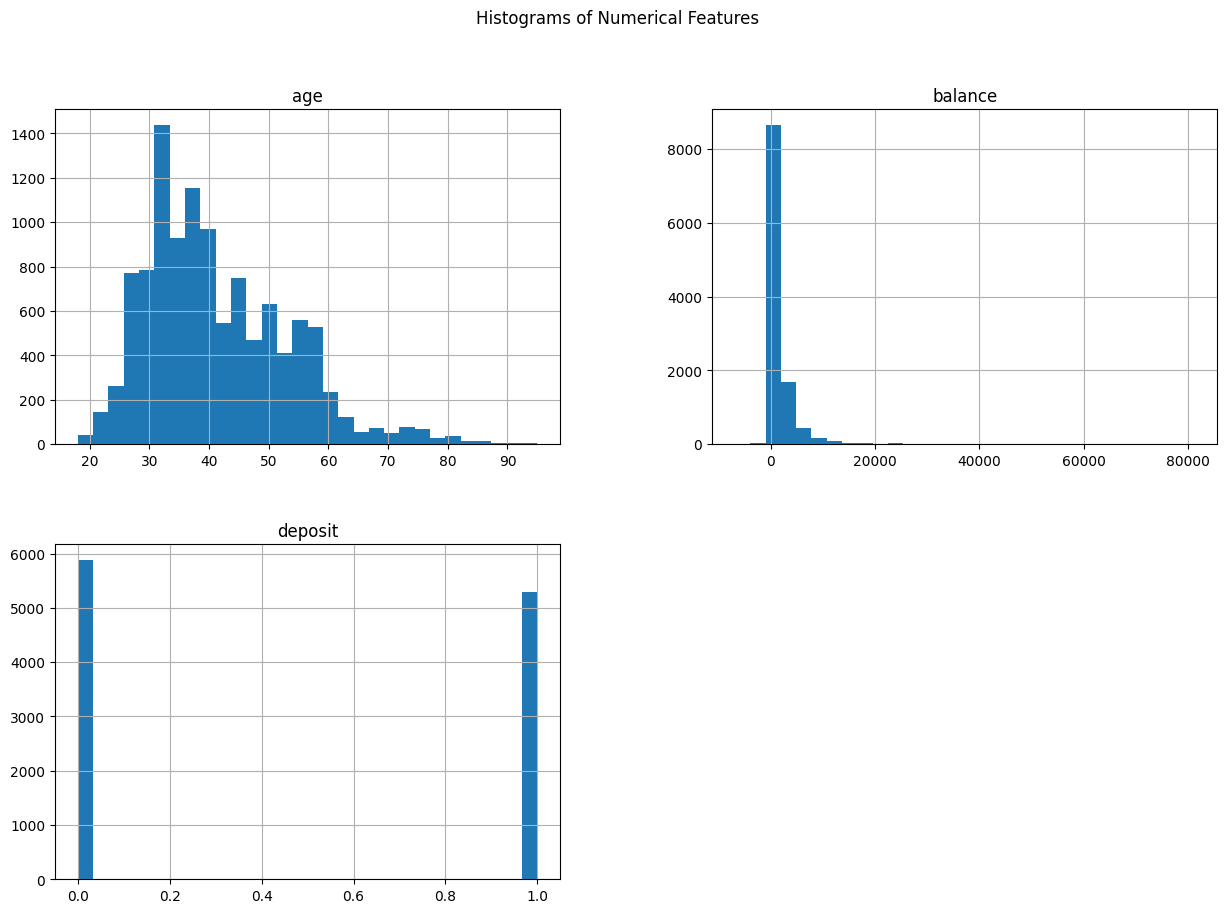

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for numerical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Features')
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

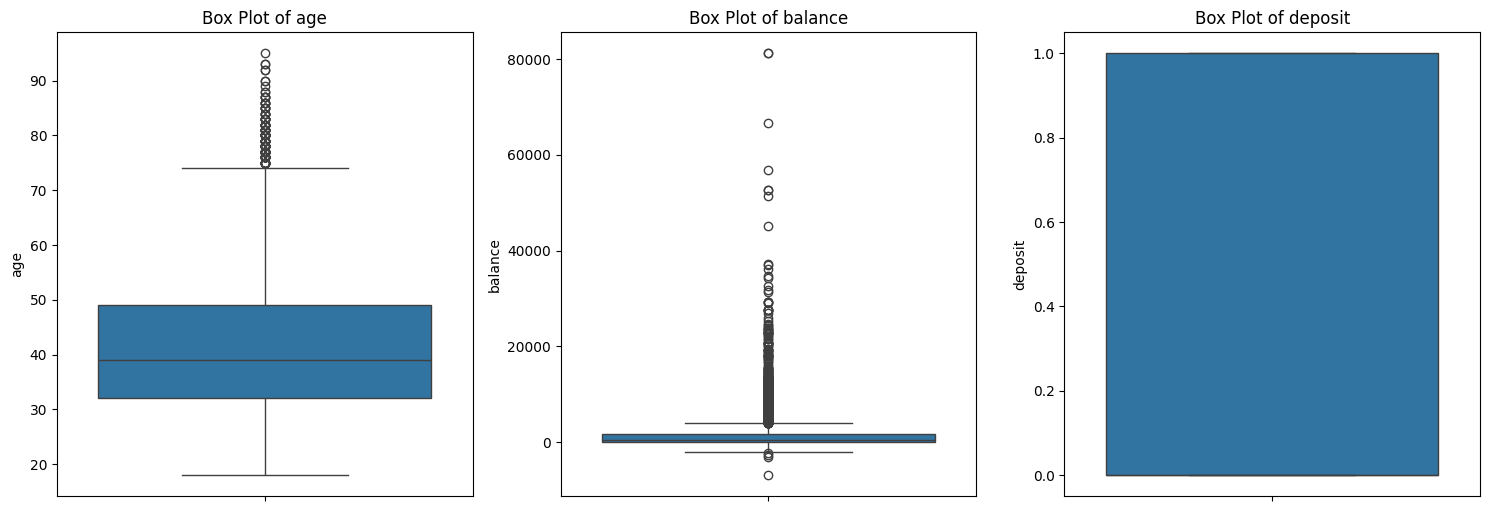

In [24]:
# Box plots for numerical features to identify outliers
plt.figure(figsize=(15, 10))
for i, column in enumerate(num_cols):
    plt.subplot(len(num_cols) // 3 + 1, 3, i + 1)
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1687/3691346983.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], order = df[column].value_counts().index, palette='viridis')
/tmp/ipykernel_1687/3691346983.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], order = df[column].value_counts().index, palette='viridis')
/tmp/ipykernel_1687/3691346983.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], order = df[column].value_counts().index, palette='viridis')
/tmp/ipykernel_1687/3691346983.py:6: FutureWarning: 

Passing `palette

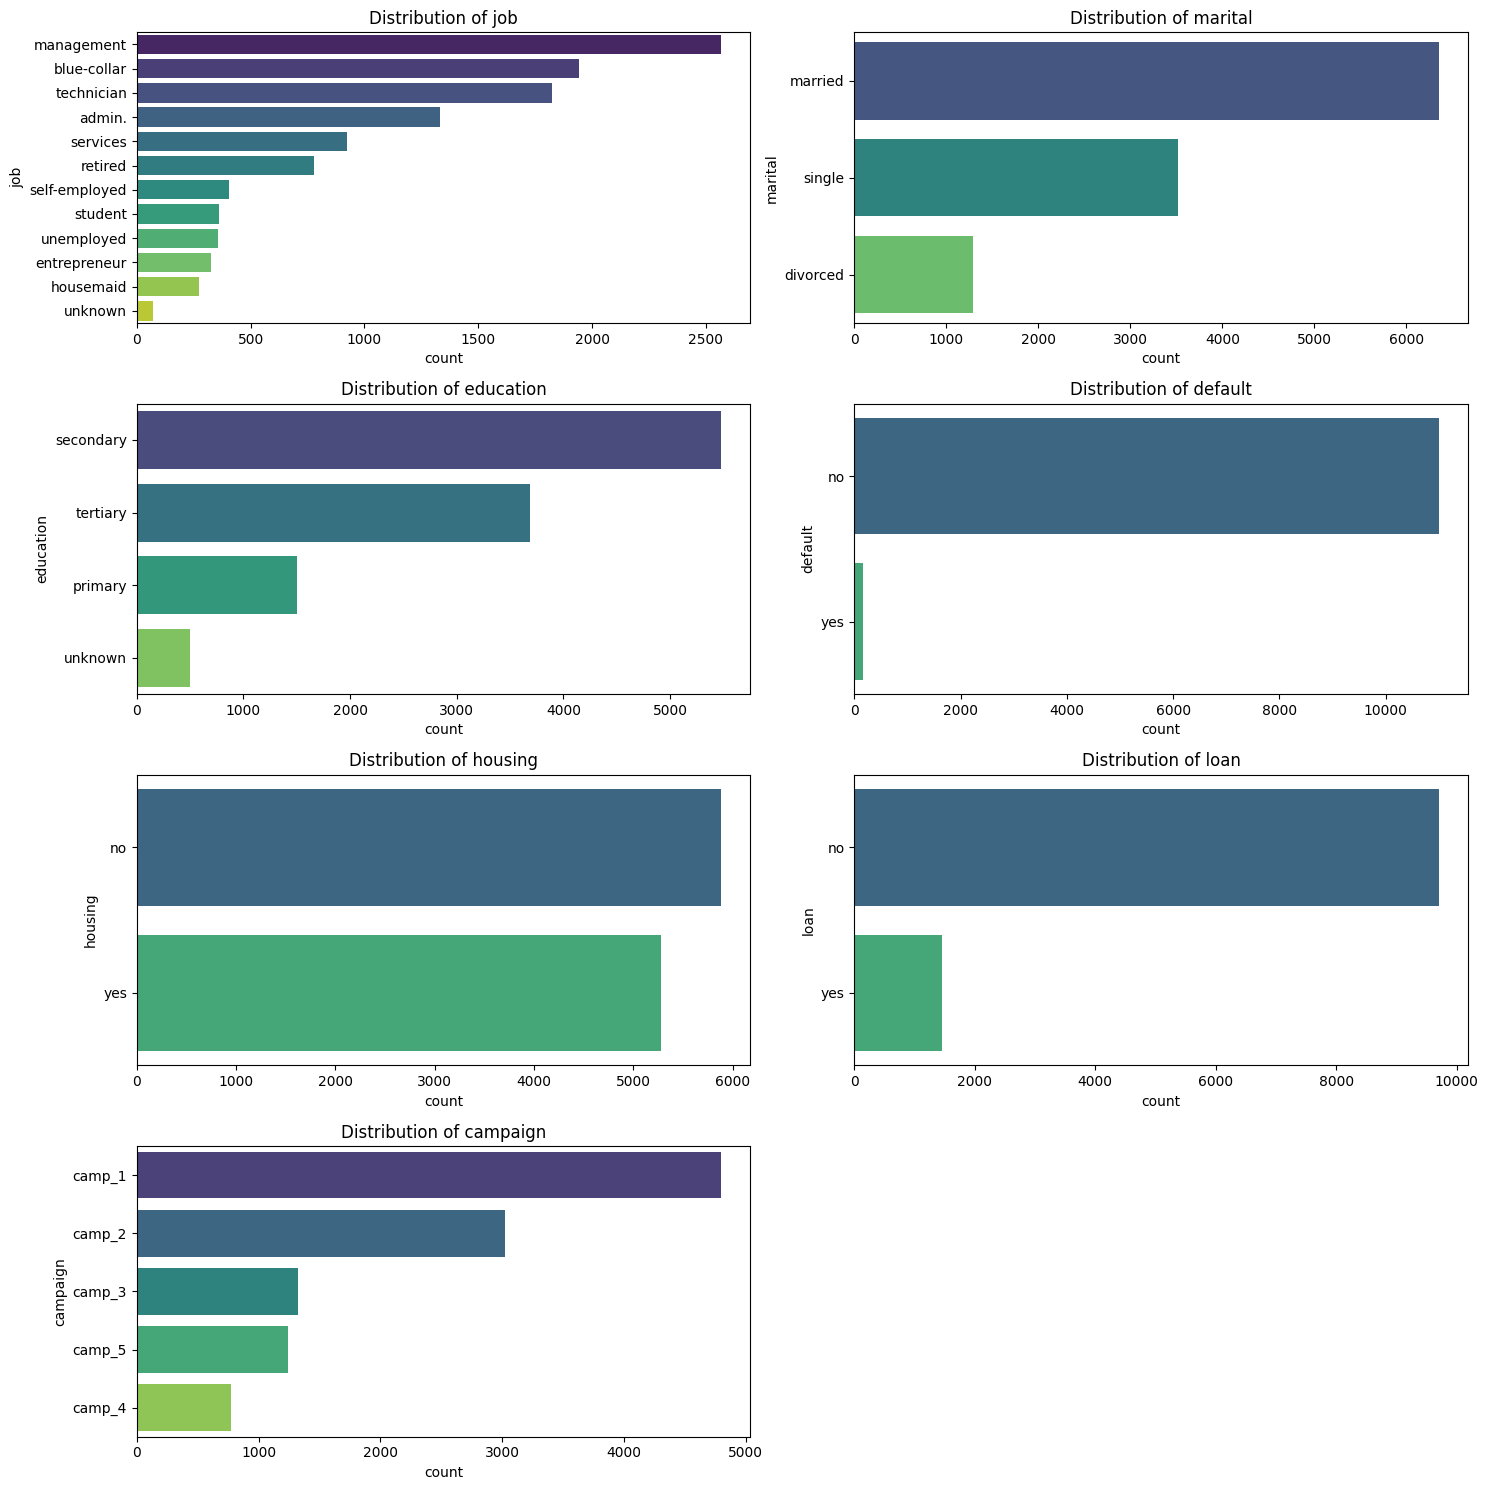

In [25]:
# Bar plots for categorical features
cat_cols = df.select_dtypes(include='object').columns
plt.figure(figsize=(15, 15))
for i, column in enumerate(cat_cols):
    plt.subplot(len(cat_cols) // 2 + 1, 2, i + 1) # Adjust subplot grid dynamically
    sns.countplot(y=df[column], order = df[column].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.show()

### 7. Correlation Analysis (קורלציה)

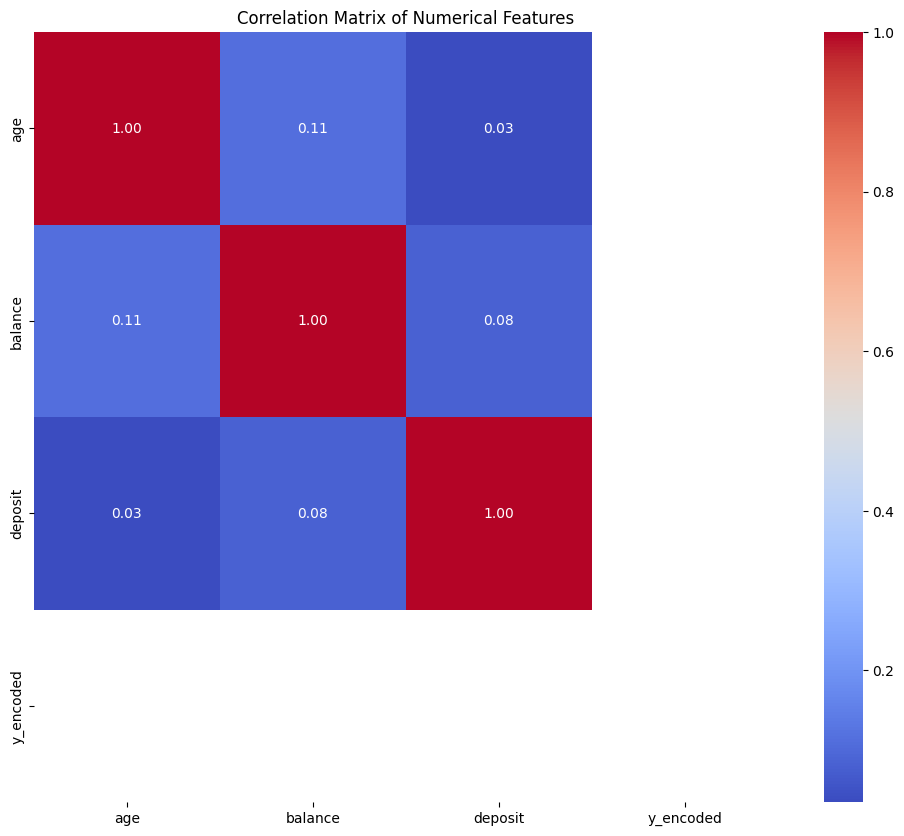

In [26]:
# Convert target variable 'y' to numerical for correlation calculation
df_corr = df.copy()
df_corr['y_encoded'] = df_corr['deposit'].map({'no': 0, 'yes': 1})

# Select only numerical columns for correlation matrix
correlation_matrix = df_corr.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [44]:
import numpy as np

def calculate_woe_iv(dataset, feature, target):
    lst = []
    for i in range(dataset[feature].nunique()):
        val = list(dataset[feature].unique())[i]
        lst.append({
            'Value': val,
            'All': dataset[dataset[feature] == val].count()[feature],
            'Good': dataset[(dataset[feature] == val) & (dataset[target] == 0)].count()[feature],
            'Bad': dataset[(dataset[feature] == val) & (dataset[target] == 1)].count()[feature]
        })

    d3 = pd.DataFrame(lst)
    d3['Distr_Good'] = d3['Good'] / d3['Good'].sum()
    d3['Distr_Bad'] = d3['Bad'] / d3['Bad'].sum()
    d3['WoE'] = np.log(d3['Distr_Good'] / d3['Distr_Bad'])
    d3 = d3.replace({'WoE': {np.inf: 0, -np.inf: 0}})
    d3['IV'] = (d3['Distr_Good'] - d3['Distr_Bad']) * d3['WoE']
    return d3['IV'].sum()

iv_results = {}
target = 'deposit_encoded' if 'deposit_encoded' in df.columns else 'deposit'
if df[target].dtype == 'object':
    df[target] = df[target].map({'no': 0, 'yes': 1})

# Categorical Features
cat_features = df.select_dtypes(include=['object']).columns
for col in cat_features:
    iv_results[col] = calculate_woe_iv(df, col, target)

# Numerical Features (with binning)
num_features = df.select_dtypes(include=['int64', 'float64']).columns.drop(target)
for col in num_features:
    df[f'{col}_bin'] = pd.qcut(df[col], q=10, duplicates='drop').astype(str)
    iv_results[col] = calculate_woe_iv(df, f'{col}_bin', target)
    df.drop(columns=[f'{col}_bin'], inplace=True)

iv_df = pd.DataFrame.from_dict(iv_results, orient='index', columns=['IV']).sort_values(by='IV', ascending=False)
print("Information Value (IV) Ranking:")
display(iv_df)

Information Value (IV) Ranking:


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,IV
housing,0.169373
job,0.141556
age_cat,0.105640
campaign,0.077480
loan,0.050958
education,0.044350
balance_cat,0.043152
marital,0.039452


In [34]:
# Custom Binning for Balance
balance_bins = [-float('inf'), 0, 25000, 50000, 75000, float('inf')]
balance_labels = ['til_0', '0_25K', '25K_50K', '50K_75K', '75K_UP']
df['balance_cat'] = pd.cut(df['balance'], bins=balance_bins, labels=balance_labels)

# Custom Binning for Age
age_bins = [0, 29, 49, 69, float('inf')]
age_labels = ['0_29', '30_49', '50_69', '70_up']
df['age_cat'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# Display results
display(df[['age', 'age_cat', 'balance', 'balance_cat']].head())


,age,age_cat,balance,balance_cat
0,59,50_69,2343,0_25K
1,56,50_69,45,0_25K
2,41,30_49,1270,0_25K
3,55,50_69,2476,0_25K
4,54,50_69,184,0_25K


In [38]:
# Correcting the drop operation
# We check if columns exist before dropping to avoid KeyErrors
columns_to_remove = ['age', 'balance', 'default']
existing_cols = [col for col in columns_to_remove if col in df.columns]

if existing_cols:
    df.drop(columns=existing_cols, inplace=True)

display(df.head())
print("Remaining columns:", df.columns.tolist())

,job,marital,education,housing,loan,campaign,deposit,balance_cat,age_cat
0,admin.,married,secondary,yes,no,camp_1,1,0_25K,50_69
1,admin.,married,secondary,no,no,camp_1,1,0_25K,50_69
2,technician,married,secondary,yes,no,camp_1,1,0_25K,30_49
3,services,married,secondary,yes,no,camp_1,1,0_25K,50_69
4,admin.,married,tertiary,no,no,camp_2,1,0_25K,50_69


Remaining columns: ['job', 'marital', 'education', 'housing', 'loan', 'campaign', 'deposit', 'balance_cat', 'age_cat']


In [43]:
# Convert category columns to object type
category_cols = df.select_dtypes(include=['category']).columns
df[category_cols] = df[category_cols].astype(str)

# Verify the change
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   job          11162 non-null  object
 1   marital      11162 non-null  object
 2   education    11162 non-null  object
 3   housing      11162 non-null  object
 4   loan         11162 non-null  object
 5   campaign     11162 non-null  object
 6   deposit      11162 non-null  int64 
 7   balance_cat  11162 non-null  object
 8   age_cat      11162 non-null  object
dtypes: int64(1), object(8)
memory usage: 785.0+ KB


Distributions for customers with deposit=1 (Count: 5289)


/tmp/ipykernel_1687/4254711143.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df_deposited, palette='viridis', order=df_deposited[col].value_counts().index)
/tmp/ipykernel_1687/4254711143.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df_deposited, palette='viridis', order=df_deposited[col].value_counts().index)
/tmp/ipykernel_1687/4254711143.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df_deposited, palette='viridis', order=df_deposited[col].value_counts().index)
/tmp/ipykernel_1

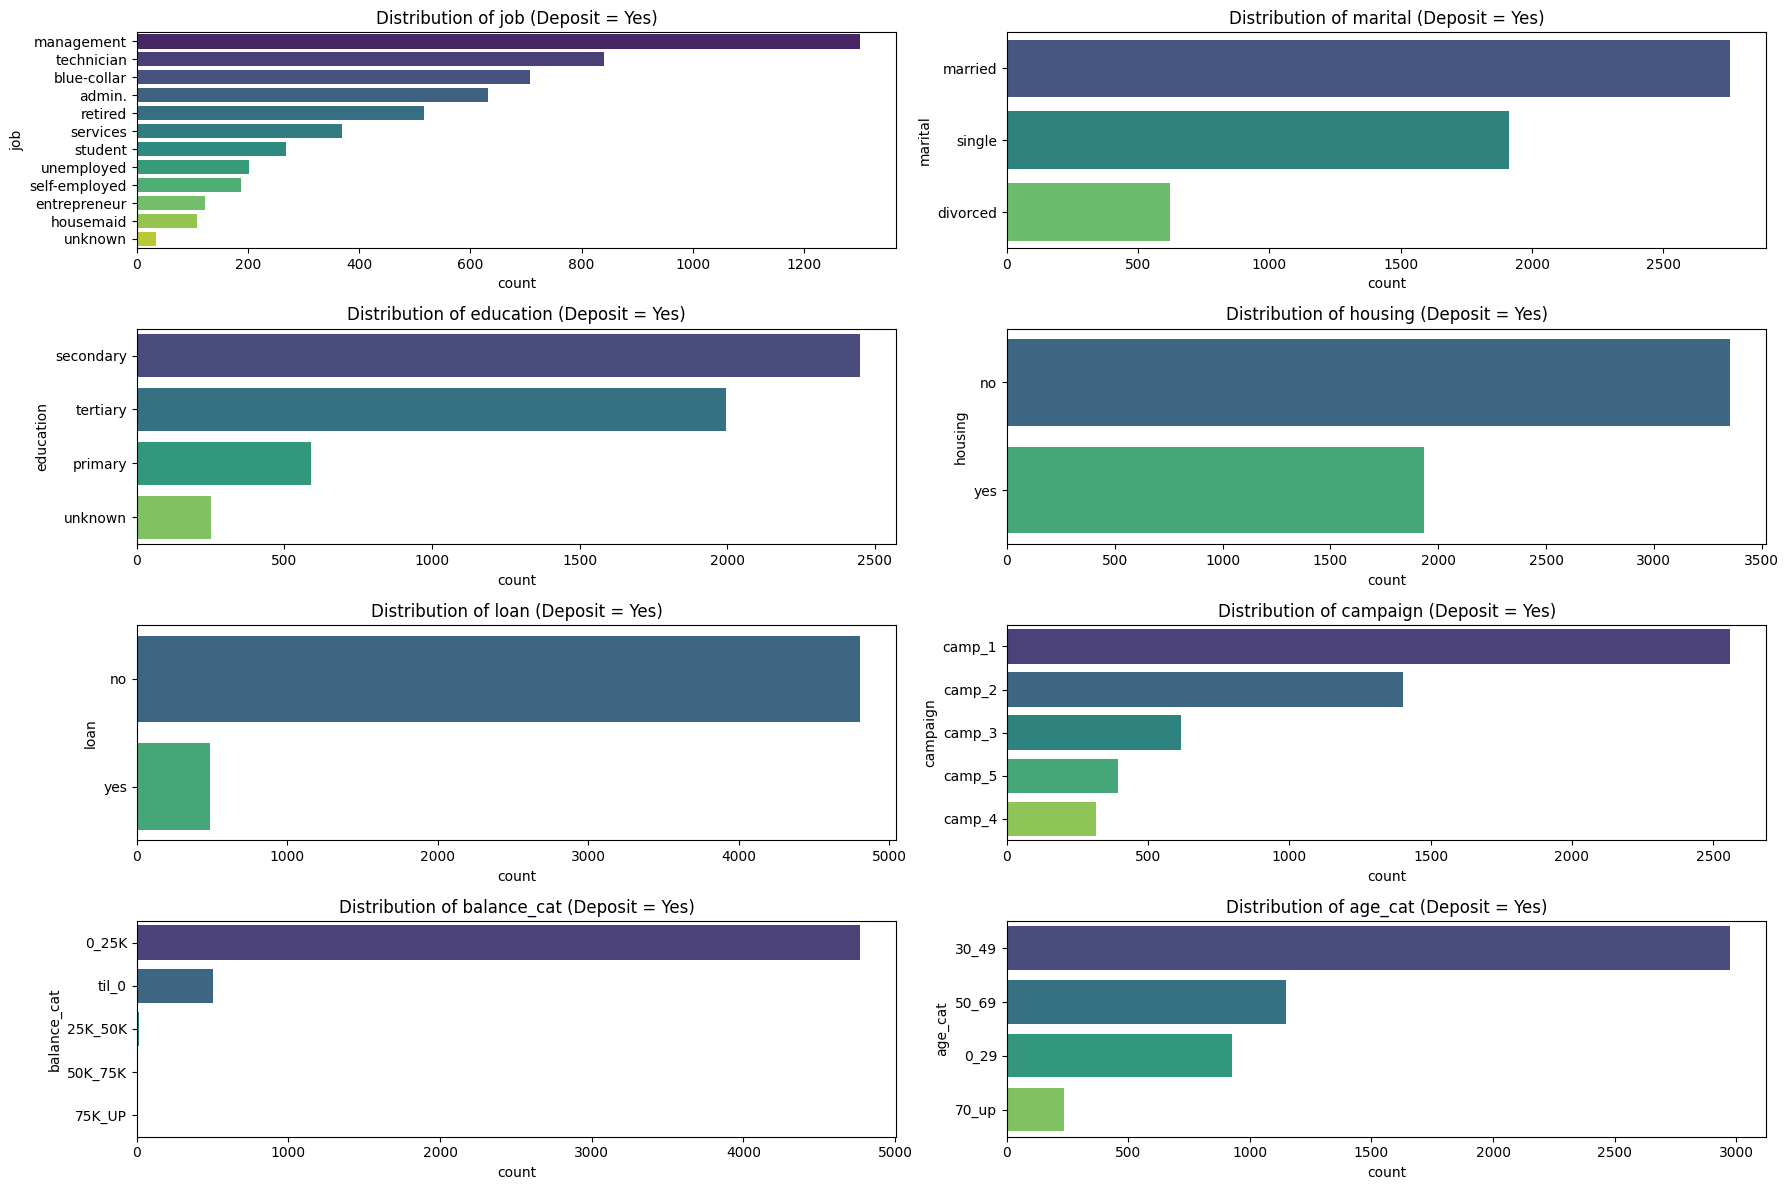

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the dataframe for customers who made a deposit
df_deposited = df[df['deposit'] == 1]

# List categorical and numerical columns (excluding the target itself)
cat_cols = df_deposited.select_dtypes(include=['object']).columns.tolist()
num_cols = df_deposited.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'deposit' in num_cols: num_cols.remove('deposit')

print(f"Distributions for customers with deposit=1 (Count: {len(df_deposited)})")

# Plot categorical distributions
plt.figure(figsize=(18, 12))
for i, col in enumerate(cat_cols):
    plt.subplot((len(cat_cols) + 1) // 2, 2, i + 1)
    sns.countplot(y=col, data=df_deposited, palette='viridis', order=df_deposited[col].value_counts().index)
    plt.title(f'Distribution of {col} (Deposit = Yes)')
plt.tight_layout()
plt.show()

# Plot numerical distributions if any exist
if num_cols:
    df_deposited[num_cols].hist(bins=20, figsize=(15, 5))
    plt.suptitle('Numerical Distributions (Deposit = Yes)')
    plt.show()

In [168]:
# Correlation with the target variable 'y_encoded'
print("Correlation with target variable 'y_encoded':")
print(correlation_matrix['y_encoded'].sort_values(ascending=False))

Correlation with target variable 'y_encoded':
y_encoded    1.000000
age          0.034901
Name: y_encoded, dtype: float64


### 8. Chi-squared Test for Categorical Features (מבחן חי-בריבוע למשתנים קטגוריאליים)

נבצע מבחן חי-בריבוע (Chi-squared test) כדי לבדוק קשר סטטיסטי בין כל אחד מהמשתנים הקטגוריאליים למשתנה המטרה `deposit`. P-value נמוך (לרוב < 0.05) יעיד על קשר מובהק.

In [169]:
from scipy.stats import chi2_contingency

target_variable = 'deposit'
cat_cols_for_chi2 = [col for col in df.select_dtypes(include='object').columns if col != target_variable]

print(f"Chi-squared test results for categorical features vs. '{target_variable}':\n")

for col in cat_cols_for_chi2:
    contingency_table = pd.crosstab(df[col], df[target_variable])
    chi2, p_value, _, _ = chi2_contingency(contingency_table)
    print(f"Column: '{col}'")
    print(f"  Chi2 Statistic: {chi2:.2f}")
    print(f"  P-value: {p_value:.3f}")
    if p_value < 0.05:
        print("  => Statistically significant relationship")
    else:
        print("  => No statistically significant relationship")
    print("----------------------------------------------")

Chi-squared test results for categorical features vs. 'deposit':

Column: 'job'
  Chi2 Statistic: 378.08
  P-value: 0.000
  => Statistically significant relationship
----------------------------------------------
Column: 'marital'
  Chi2 Statistic: 109.58
  P-value: 0.000
  => Statistically significant relationship
----------------------------------------------
Column: 'education'
  Chi2 Statistic: 122.77
  P-value: 0.000
  => Statistically significant relationship
----------------------------------------------
Column: 'housing'
  Chi2 Statistic: 463.19
  P-value: 0.000
  => Statistically significant relationship
----------------------------------------------
Column: 'loan'
  Chi2 Statistic: 135.83
  P-value: 0.000
  => Statistically significant relationship
----------------------------------------------


### 9. Continuous Features Analysis by Target Variable (ניתוח משתנים רציפים לפי משתנה מטרה)

נבחן את המאפיינים הסטטיסטיים של המשתנים הרציפים (ממוצע, חציון, קורלציה) ואת התפלגותם לפי עשירונים, הכל ביחס למשתנה המטרה `deposit` (האם הלקוח ביצע הפקדה - 'yes' או 'no').

In [170]:
# יצירת עמודת מטרה מקודדת מספרית לצורך חישובי קורלציה
df['deposit_encoded'] = df['deposit'].map({'no': 0, 'yes': 1})

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# נסיר את עמודת המטרה המקודדת המספרית מהרשימה אם היא כבר שם (כדי לא לנתח אותה כ'פיצ'ר')
if 'deposit_encoded' in num_cols:
    num_cols.remove('deposit_encoded')

print(f"Analysis of numerical features by target variable '{target_variable}':\n")

for col in num_cols:
    print(f"Column: '{col}'")
    print("  Mean by deposit:")
    print(df.groupby(target_variable)[col].mean().to_string())
    print("  Median by deposit:")
    print(df.groupby(target_variable)[col].median().to_string())
    print("  Correlation with deposit (encoded):")
    print(df[col].corr(df['deposit_encoded']))

    # Decile analysis
    print(f"\n  Distribution by Deciles for '{col}' (proportion of 'yes' deposit):")
    df['{}_decile'.format(col)] = pd.qcut(df[col], q=10, labels=False, duplicates='drop')
    decile_analysis = df.groupby('{}_decile'.format(col))['deposit_encoded'].mean().reset_index()
    decile_analysis.rename(columns={'deposit_encoded': 'proportion_deposit_yes'}, inplace=True)
    print(decile_analysis.to_string(index=False))
    print("----------------------------------------------\n")

# הסרת עמודת העזר שנוצרה לקידוד המטרה ולעשירונים
df.drop(columns=['deposit_encoded'] + [f'{col}_decile' for col in num_cols if f'{col}_decile' in df.columns], inplace=True, errors='ignore')

Analysis of numerical features by target variable 'deposit':

Column: 'age'
  Mean by deposit:
deposit
no     40.837391
yes    41.670070
  Median by deposit:
deposit
no     39.0
yes    38.0
  Correlation with deposit (encoded):
0.03490092789028266

  Distribution by Deciles for 'age' (proportion of 'yes' deposit):
 age_decile  proportion_deposit_yes
          0                0.618970
          1                0.464062
          2                0.458023
          3                0.442973
          4                0.428705
          5                0.377174
          6                0.425379
          7                0.397901
          8                0.417870
          9                0.713693
----------------------------------------------



## Pre-processing

In [141]:
# each variable need to be clean.

In [171]:
df['deposit'] = df['deposit'].map({'no': 0, 'yes': 1})
display(df.head())

,age,job,marital,education,housing,loan,deposit
0,59,admin.,married,secondary,yes,no,1
1,56,admin.,married,secondary,no,no,1
2,41,technician,married,secondary,yes,no,1
3,55,services,married,secondary,yes,no,1
4,54,admin.,married,tertiary,no,no,1


In [172]:
df

,age,job,marital,education,housing,loan,deposit
0,59,admin.,married,secondary,yes,no,1
1,56,admin.,married,secondary,no,no,1
2,41,technician,married,secondary,yes,no,1
3,55,services,married,secondary,yes,no,1
4,54,admin.,married,tertiary,no,no,1
...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,yes,no,0
11158,39,services,married,secondary,no,no,0
11159,32,technician,single,secondary,no,no,0
11160,43,technician,married,secondary,no,yes,0


In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   housing    11162 non-null  object
 5   loan       11162 non-null  object
 6   deposit    11162 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 610.6+ KB


In [ ]:
"""
WOE / IV Checklist

For each feature:

1. Define target orientation:
   good = target == 0
   bad  = target == 1

2. Prepare feature:
   - handle missing
   - group rare categories
   - if numeric -> create bins

3. Build summary table by bin/category:
   - total_count
   - good_count
   - bad_count

4. Calculate:
   good_dist = good_count / total_good
   bad_dist  = bad_count / total_bad
   WOE = ln(good_dist / bad_dist)
   IV_component = (good_dist - bad_dist) * WOE

5. Final IV:
   IV = sum(IV_component)

6. Review:
   - predictive strength
   - monotonicity
   - sparse bins
   - leakage suspicion
"""

In [ ]:
# Perform One-Hot Encoding on categorical features
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if 'deposit' in categorical_cols:
    categorical_cols.remove('deposit')

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

display(df.head())

## Train / Test

In [150]:
x = df.drop('deposit', axis=1)
y = df['deposit']

print("Shape of features (x):", x.shape)
print("Shape of target (y):", y.shape)

Shape of features (x): (11162, 19)
Shape of target (y): (11162,)


## Feature selection

/tmp/ipykernel_19104/3313669881.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


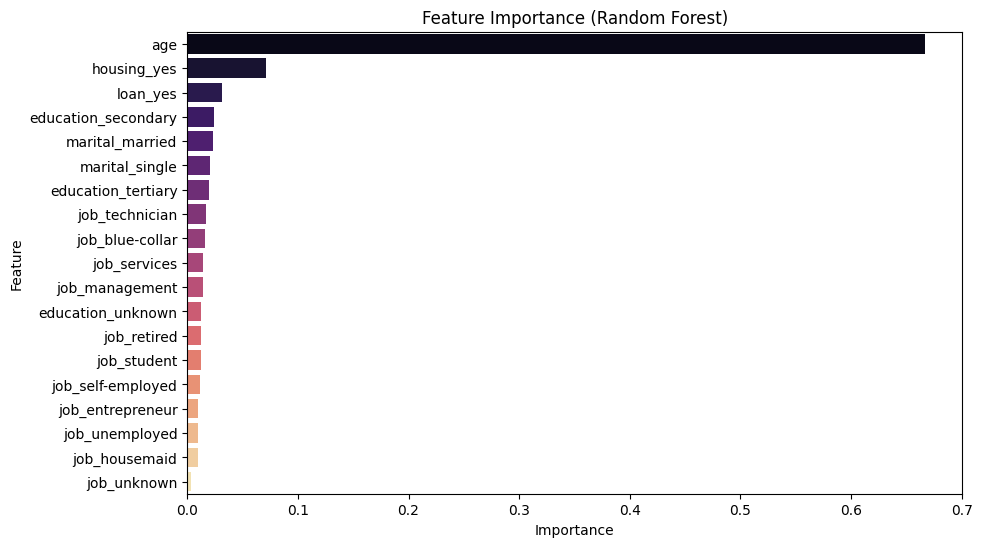

,Feature,Importance
0,age,0.667143
17,housing_yes,0.070825
18,loan_yes,0.031577
14,education_secondary,0.024153
12,marital_married,0.023211
13,marital_single,0.020352
15,education_tertiary,0.019737
9,job_technician,0.016934
1,job_blue-collar,0.016110
7,job_services,0.014028


In [151]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Initialize and fit Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x, y)

# Get feature importances
importances = rf.feature_importances_
feature_names = x.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Feature Importance (Random Forest)')
plt.show()

display(feature_importance_df)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Lasso (L1) works best when features are scaled
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Initialize Logistic Regression with L1 penalty (Lasso)
# C is the inverse of regularization strength; smaller values specify stronger regularization.
log_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)
log_lasso.fit(x_scaled, y)

# Create a dataframe for the coefficients
lasso_coeffs = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': log_lasso.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Features selected by Lasso (Non-zero coefficients):")
display(lasso_coeffs[lasso_coeffs['Coefficient'] != 0])

# Visualize coefficients
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=lasso_coeffs, palette='coolwarm')
plt.title('Logistic Regression (Lasso L1) Coefficients')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

## Baseline running

## Evaluation

## README - HOW TO USING IN PRODUCTION